In [1]:
# %% [markdown]
# ## Gain-Scheduled Controller Simulation and Data Analysis (CcaS/CcaR TCS)

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lmfit
import warnings
warnings.filterwarnings("ignore")

from model_and_controller_equations.run_all_controllers import run_control
from model_and_controller_equations.run_constant import run_constant
from signal_analysis import analyze_signal

In [2]:
## Experimental Data Processing 


# Load experimental fluorescence datasets
data1 = pd.read_csv('experiment_data/P-FL_OD_run_data_042325.csv')
data2 = pd.read_csv('experiment_data/P-FL_OD_run_data_040625.csv')

# Extract experimental replicates
P1_data1 = data1[['SP1_1', 'SP1_2', 'SP1_3', 'SP1_4', 'SP1_5', 'SP1_6']].to_numpy()
P2_data1 = data1[['SP2_1', 'SP2_2', 'SP2_3', 'SP2_4', 'SP2_5', 'SP2_6']].to_numpy()

P1_data2 = data2[['SP1_1', 'SP1_2', 'SP1_3']].to_numpy()
P2_data2 = data2[['SP2_1', 'SP2_2', 'SP2_3']].to_numpy()

green_data1 = data1[['G1']].to_numpy()
green_data2 = data2[['G1', 'G2', 'G3']].to_numpy()
red_data1 = data1[['R1']].to_numpy()
red_data2 = data2[['R1', 'R2', 'R3']].to_numpy()

# Truncate all data to shared minimum length
min_len = min(P1_data1.shape[0], P1_data2.shape[0])
P1_data1 = P1_data1[:min_len]; P2_data1 = P2_data1[:min_len]
P1_data2 = P1_data2[:min_len]; P2_data2 = P2_data2[:min_len]
green_data1 = green_data1[:min_len]; green_data2 = green_data2[:min_len]
red_data1 = red_data1[:min_len]; red_data2 = red_data2[:min_len]

# %%
# Merge all experimental replicates
P1_all = np.hstack((P1_data1, P1_data2))
P2_all = np.hstack((P2_data1, P2_data2))
green_all = np.hstack((green_data1, green_data2))
red_all = np.hstack((red_data1, red_data2))

# Compute means and standard deviations
P1_mean = np.mean(P1_all, axis=1)
P1_std = np.std(P1_all, axis=1)
P2_mean = np.mean(P2_all, axis=1)
P2_std = np.std(P2_all, axis=1)
green_mean = np.mean(green_all, axis=1)
green_std = np.std(green_all, axis=1)
red_mean = np.mean(red_all, axis=1)
red_std = np.std(red_all, axis=1)

# Normalize scale using green max
green_max = np.max(green_mean)

# Normalize experimental data
P1_mean_norm = P1_mean / green_max
P1_std_norm = P1_std / green_max
P2_mean_norm = P2_mean / green_max
P2_std_norm = P2_std / green_max
green_mean_norm = green_mean / green_max
green_std_norm = green_std / green_max
red_mean_norm = red_mean / green_max
red_std_norm = red_std / green_max

In [3]:
# Some User Defined Inputs
# Time parameters
interval = 10
time_exp = np.arange(interval, (min_len + 1) * interval, interval)
t_final = 16 * 60

# Setpoints from experiments
st_pt_1 = 11500
st_pt_2 = 18500


# Color dictionary
color_dict = {
    'set_point_1': '#6759d4',
    'set_point_2': '#d9d9d9',
    'green': 'green',
    'red': 'red',
    'PID': 'black',
    'PID-GS': '#1f78b4', 
    'FF': '#dd3497',
    'PID-FF': '#fc8d62',
    'PID-GS-FF': '#03cea4'
}

In [4]:
## Load the Model Parameters 


p = pd.read_csv('parameters/TCS_params_guess_070225.csv').to_numpy()

p = p[:,2]

params = lmfit.Parameters()

params.add(name = 'k_green', value = p[0], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_red', value = p[1], min = 1e0, max = 1e4, vary = 1)
params.add(name = 'b_green', value = p[2], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'b_red', value = p[3], min = 1e0, max = 1e4, vary = 1)

params.add(name = 'k_sp_b', value = p[4], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_sp_u', value = p[5], min = 1e-4, max = 1e4, vary = 1)

params.add(name = 'k_rp_b', value = p[6], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_rp_u', value = p[7], min = 1e-4, max = 1e4, vary = 1)

params.add(name = 'beta', value = p[8], min = 1e-1, max = 500, vary = 1)
params.add(name = 'l0', value = p[9], min = 0, max = 0.5, vary = 1)
params.add(name = 'Kc', value = p[10], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'd_m', value = p[11], min = 0.05, max = 0.35, vary = 1)
params.add(name = 'k_tl', value = p[12], min = 0.05, max = 10, vary = 1)
params.add(name = 'k_tli_b', value = p[13], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_tli_u', value = p[14], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'd_p', value = p[15], min = 1e-6, max = 1e-1, vary = 1)
params.add(name = 'k_fold', value = p[16], min = 0.05, max = 0.3, vary = 1)
params.add(name = 'b_fold', value = p[17], min = 0.1, max = 2, vary = 1)
params.add(name = 'n_gamma', value = p[18], min = 0.05, max = 0.9, vary = 1)
params.add(name = 'R_max', value = p[19], min = 1e0, max = 1e4, vary = 1)

params.add(name = 'S_0', value = p[20], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'R_0', value = p[21], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Sp_0', value = p[22], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Rp_0', value = p[23], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'mRNA_0', value = p[24], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'P_0', value = p[25], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Pm_0', value = p[26], min = 1e-4, max = 1e4, vary = 1)


params.add(name = 'k_gr', value = p[27], vary = 0)
params.add(name = 'C_max', value = p[28], vary = 0)
params.add(name = 'C_0', value = p[29], vary = 0)

params.add(name = 'n_tcs', value = p[30], min = 0.1, max = 5, vary = 1)

# define initial conditions and solve the ODEs

x0 = np.zeros(11)

x0[0] = p[20] # S
x0[1] = p[22]# Sp
x0[2] = p[21] # R
x0[3] = p[23] # Rp
x0[4] = 0 # Ac
x0[5] = p[24] # mRNA
x0[6] = 0 # Ctic
x0[7] = p[25] # Unfolded Protein 
x0[8] = p[26] # Folded Protein 
x0[9] = p[29] # Initial Cell count
x0[10] = 0 # Initial Integral Error

t_final = 960

In [5]:
# Simulate constant inputs (open loop) without any disturbance for baseline measurement

time_green_no_perturbn, _, sol_green_no_perturbn = run_constant(t_final, x0, params, constant_input = 'green', growth_perturb=0)
time_red_no_perturbn, _, sol_red_no_perturbn = run_constant(t_final, x0, params, constant_input = 'red', growth_perturb=0)
time_dark_no_perturbn, _, sol_dark_no_perturbn = run_constant(t_final, x0, params, constant_input = 'dark', growth_perturb=0)

st_pt_1_model = st_pt_1 * (np.max(sol_green_no_perturbn[:,8]))/green_max
st_pt_2_model = st_pt_2 * (np.max(sol_green_no_perturbn[:,8]))/green_max

### Simulation of different controller stratgeies for disturbance rejection

In [6]:
# Controller parameters

# simulate the pre-run step under constant green light
def closest_index(timepoints, target):
    tp = np.asarray(timepoints)
    i = np.searchsorted(tp, target, side="left")
    if i == 0:
        return 0
    if i == len(tp):
        return len(tp) - 1
    return i-1 if (target - tp[i-1]) <= (tp[i] - target) else i

t_rerun = 100
i_rerun = closest_index(time_green_no_perturbn, t_rerun)
x0 = sol_green_no_perturbn[i_rerun, :] # update the initial condition based on the pre-run

# Convert the units of gains and setpoints in the experiment to simulation units using the scaling factor
scaling_factor = (green_max/(np.max(sol_green_no_perturbn[:,8]))) * (1/60) 

pid_gain = 0.032 * scaling_factor
FF_gain = 0.8 * scaling_factor
PID_FF_gain = 0.8 * scaling_factor

tolerence_percentage = 0.05 # if X, then tolerence band is X * max(dynamic range)


# perturbation parameters
perturb_percent = 80 # If the sample is diluted by X%, the final OD equals the original (pre-dilution) OD multiplied by (100 − X)/100.
perturb_time = 480 # perturbation happens at this time (post the pre-run)
new_t_final = 16*60 # new experiment end time after perturbation


# Simulate constant inputs (open loop)
time_green_with_perturbn, _, sol_green_with_perturbn = run_constant(t_final, x0, params, constant_input = 'green', growth_perturb=1,
                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                 new_t_final=new_t_final)

time_red_with_perturbn, _, sol_red_with_perturbn = run_constant(t_final, x0, params, constant_input = 'red', growth_perturb=1,
                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                 new_t_final=new_t_final)


# Simulate disturbance rejection using Gain Scheduled PID, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID_GS, ctrl_SP2_PID_to_PID_GS, sol_SP2_PID_to_PID_GS, t_green_on_SP2_PID_to_PID_GS,  opt_times_SP2_PID_to_PID_GS = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID-GS",
                                                                print_perturb_message=True)

# # Simulate disturbance rejection using plain Feed Forward (FF), with pre-disturbance controller being plain PID. Equilibrium point is SP2
# t_SP2_PID_to_FF, ctrl_SP2_PID_to_FF, sol_SP2_PID_to_FF, t_green_on_SP2_PID_to_FF,  opt_times_SP2_PID_to_FF = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
#                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
#                                                                 new_t_final=new_t_final,
#                                                                 initial_controller="PID",switch_to_controller="FF", FF_gain=FF_gain,
#                                                                 print_perturb_message=True)

# # Simulate disturbance rejection using combined PID-FF, with pre-disturbance controller being plain PID. Equilibrium point is SP2
# t_SP2_PID_to_PID_FF, ctrl_SP2_PID_to_PID_FF, sol_SP2_PID_to_PID_FF, t_green_on_SP2_PID_to_PID_FF,  opt_times_SP2_PID_to_PID_FF = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
#                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
#                                                                 new_t_final=new_t_final,
#                                                                 initial_controller="PID",switch_to_controller="PID-FF", FF_gain=PID_FF_gain,
#                                                                 print_perturb_message=True)

# Simulate disturbance rejection using combined PID-GS-FF, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID_GS_FF, ctrl_SP2_PID_to_PID_GS_FF, sol_SP2_PID_to_PID_GS_FF, t_green_on_SP2_PID_to_PID_GS_FF,  opt_times_SP2_PID_to_PID_GS_FF = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID-GS-FF", FF_gain=PID_FF_gain,
                                                                print_perturb_message=True)


# Simulate disturbance rejection using plain PID, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID, ctrl_SP2_PID_to_PID, sol_SP2_PID_to_PID, t_green_on_SP2_PID_to_PID,  opt_times_SP2_PID_to_PID = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID",
                                                                print_perturb_message=True)

Perturbing now
Perturbation applied at time 480 to bring to 12.719626168224298 minutes
Perturbing now
Perturbation applied at time 480 to bring to 12.719626168224298 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 12.667310943928669 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 12.667310943928669 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 12.667310943928669 minutes


In [7]:
# Normalize simulation and experimental outputs
green_sim_norm = sol_green_with_perturbn[:,8] / np.max(sol_green_no_perturbn[:,8])
red_sim_norm = sol_red_with_perturbn[:,8] / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_PID_GS_norm = np.array(ctrl_SP2_PID_to_PID_GS) / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_PID_GS_FF_norm = np.array(ctrl_SP2_PID_to_PID_GS_FF) / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_PID_norm = np.array(ctrl_SP2_PID_to_PID) / np.max(sol_green_no_perturbn[:,8])

dynamic_range_norm = np.max(sol_green_no_perturbn[:,8] - sol_red_no_perturbn[:,8])  / np.max(sol_green_no_perturbn[:,8])

time_extent = min((max(time_green_with_perturbn), max(time_red_with_perturbn), max(t_SP2_PID_to_PID_GS)))

# extract growth profiles 
growth_green_with_perturbn = sol_green_with_perturbn[:,9] 
growth_red_with_perturbn = sol_red_with_perturbn[:,9] 

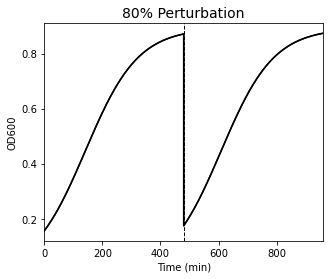

In [8]:
# Plot the growht perturbation 

fig, ax = plt.subplots(figsize=(5, 4))

# Style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10
})
# Line width and alpha
lwd = 2
alp = 0.3

ax.plot(time_green_with_perturbn, growth_green_with_perturbn/8e8, 'k')
ax.plot(time_red_with_perturbn, growth_red_with_perturbn/8e8, 'k')
ax.set_xlabel('Time (min)')
ax.set_ylabel('OD600')
ax.set_xlim(0, time_extent)


ax.set_title(f"{perturb_percent}% Perturbation")

ax.axvline(x=perturb_time, color='black', linestyle='--', linewidth=1)

In [9]:
def compute_performance_metric(ts_array, ITAE_array):
    """Computes a combined performance metric from settling times (ts) and ITAE.
    """
    ts = np.asarray(ts_array, dtype=float)
    itae = np.asarray(ITAE_array, dtype=float)

    if ts.shape != itae.shape:
        raise ValueError("ts_array and ITAE_array must have the same shape")
    
    min_perturb_time = 6 * 60 # the culture should grow for at least 6 hours before perturbation
     
    # itae max should be the integrated error if the system never settles within tolerence and we have a constant error equal to the tolerence band
    itae_max = tolerence_percentage * dynamic_range_norm * (new_t_final - min_perturb_time) * (new_t_final - min_perturb_time)/2
    ts_max = new_t_final - min_perturb_time

    ts_norm = ts/ts_max
    itae_norm = itae/itae_max

    metric = np.sqrt(ts_norm**2 + itae_norm**2)
    return metric

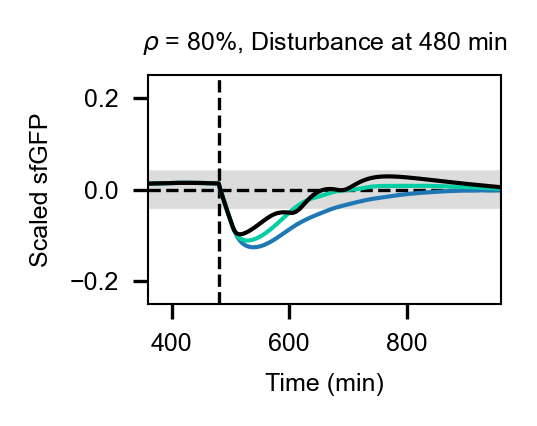

In [10]:
# %%
# Scaled disturbance plot
# Fully customizable styling for this plot

scaled_disturbance_cfg = {
    'figsize': (1.75, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 6,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'line_width': 1.0,
    'tol_linewidth': 0.5,
    'perturb_linewidth': 0.8,
    'axis_linewidth': 0.5,
    'legend_loc': 'lower right',
    'legend_bbox_to_anchor': (1, 0),
    'legend_borderpad': 0.1,
    'legend_labelspacing': 0.2,
    'legend_handletextpad': 0.3,
    'legend_handlelength': 1.2,
    'tol_alpha': 0.90,
    'ylim': (-0.5, 0.5),
    'right_margin': 0.75
}

plt.rcParams.update({
    'font.family': scaled_disturbance_cfg['font_family'],
    'font.size': scaled_disturbance_cfg['base_fontsize'],
    'axes.labelsize': scaled_disturbance_cfg['label_fontsize'],
    'axes.titlesize': scaled_disturbance_cfg['title_fontsize'],
    'legend.fontsize': scaled_disturbance_cfg['legend_fontsize']
})

# scaling is done as: (setpoint - signal)
fig, ax = plt.subplots(
    figsize=scaled_disturbance_cfg['figsize'],
    dpi=scaled_disturbance_cfg['dpi']
)

# Tolerance band
tol_band_norm = dynamic_range_norm * tolerence_percentage

upper_tol_SP2 = np.ones_like(t_SP2_PID_to_PID_GS) * tol_band_norm
lower_tol_SP2 = np.ones_like(t_SP2_PID_to_PID_GS) * (-tol_band_norm)

# Horizontal set point
ax.axhline(
    y=0,
    color='k',
    linestyle='--',
    linewidth=scaled_disturbance_cfg['perturb_linewidth']
)


band = ax.fill_between(
    t_SP2_PID_to_PID_GS,
    lower_tol_SP2,
    upper_tol_SP2,
    color=color_dict['set_point_2'],
    alpha=scaled_disturbance_cfg['tol_alpha'],
    linewidth=0
)
band.set_rasterized(True)

# Vertical line to indicate time of perturbation
ax.axvline(
    x=perturb_time,
    color='black',
    linestyle='--',
    linewidth=scaled_disturbance_cfg['perturb_linewidth']
)

# Model predictions
ax.plot(
    t_SP2_PID_to_PID_GS,
    ctrl_SP2_PID_to_PID_GS_norm - st_pt_2 / green_max,
    color=color_dict['PID-GS'],
    linewidth=scaled_disturbance_cfg['line_width'],
    label='PID-GS'
)


ax.plot(
    t_SP2_PID_to_PID_GS_FF,
    ctrl_SP2_PID_to_PID_GS_FF_norm - st_pt_2 / green_max,
    color=color_dict['PID-GS-FF'],
    linewidth=scaled_disturbance_cfg['line_width'],
    label='PID-GS-FF'
)

ax.plot(
    t_SP2_PID_to_PID,
    ctrl_SP2_PID_to_PID_norm - st_pt_2 / green_max,
    color=color_dict['PID'],
    linewidth=scaled_disturbance_cfg['line_width'],
    label='PID'
)

# Axes
ax.set_xlabel('Time (min)', fontsize=scaled_disturbance_cfg['label_fontsize'])
ax.set_ylabel('Scaled sfGFP', fontsize=scaled_disturbance_cfg['label_fontsize'])
ax.set_title(
    rf"$\rho$ = {perturb_percent}%, Disturbance at {perturb_time} min",
    fontsize=scaled_disturbance_cfg['title_fontsize']
)

ax.set_ylim(-0.25, 0.25)
ax.set_xlim(360, new_t_final)

# Legend
# ax.legend(
#     loc=scaled_disturbance_cfg['legend_loc'],
#     frameon=False,
#     bbox_to_anchor=scaled_disturbance_cfg['legend_bbox_to_anchor'],
#     borderpad=scaled_disturbance_cfg['legend_borderpad'],
#     labelspacing=scaled_disturbance_cfg['legend_labelspacing'],
#     handletextpad=scaled_disturbance_cfg['legend_handletextpad'],
#     handlelength=scaled_disturbance_cfg['legend_handlelength'],
#     fontsize=scaled_disturbance_cfg['legend_fontsize']
# )

# Spine control
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(scaled_disturbance_cfg['axis_linewidth'])

# Ticks
ax.tick_params(axis='both', which='major', labelsize=scaled_disturbance_cfg['tick_fontsize'])

# Layout
fig.subplots_adjust(right=scaled_disturbance_cfg['right_margin'])
plt.tight_layout()

# Save if needed
#plt.savefig('figures/controller_comparison_'+str(perturb_percent)+'_percent.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)
#plt.savefig('figures/controller_comparison_'+str(perturb_percent)+'_percent_with_legend.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)

## Parameter Sweep Analysis

In [11]:
# Prepare results data structure for the parameter sweep: 

results = []  # list of dict rows

controller_keys = ["PID-GS", "FF", "PID-FF", "PID-GS-FF", "PID"] # simulate all possible combinations if needed

def safe_metric_after_disturbance(err, t, perturb_time, tol_band, dyn_range, settle_cap):
    rise_t, settle_t, overshoot, ITAE = analyze_signal(
        err, t,
        0.0,
        tol_band,
        dyn_range,
        settle_time_cap=settle_cap,
        perturbed_time=perturb_time
    )

    if settle_t is None or (isinstance(settle_t, float) and np.isnan(settle_t)):
        t_settle_after = np.inf
    else:
        t_settle_after = max(0.0, float(settle_t) - float(perturb_time))

    return {
        "rise_time": rise_t,
        "settling_time": settle_t,
        "t_settle_after": t_settle_after,
        "overshoot": overshoot,
        "ITAE": ITAE,
    }

Uncomment the cell below to run the parameter sweep and save the results. I don't recommend it running every time since it takes some time.

In [12]:
# # --- Plot settings ---
# plt.rcParams.update({
#     "font.family": "Arial",
#     "font.size": 12,
#     "axes.labelsize": 12,
#     "axes.titlesize": 12,
#     "legend.fontsize": 12
# })


# perturb_percents = [20, 30, 40, 50, 60, 70, 80]
# perturb_times    = [360, 390, 420, 450, 480, 510, 540]


# new_t_final = 16*60

# # normalize everything to the no-perturb green max (model output at index 8)
# norm_factor = np.max(sol_green_no_perturbn[:, 8])

# # dynamic range (normalized) to set tolerance bands
# dynamic_range_norm = np.max(sol_green_no_perturbn[:, 8] - sol_red_no_perturbn[:, 8]) / norm_factor

# # tolerance band as a fraction of dynamic range (match what you want visually)
# tol_frac = tolerence_percentage
# tol_band_norm = dynamic_range_norm * tol_frac

# # setpoint in the *same normalized plotting scale*
# setpoint_norm = st_pt_2 / green_max  # constant used for plotting error as (pctrl_norm - setpoint_norm)

# # helper to compute "settling after perturbation"
# def metric_after_disturbance(signal, t, perturb_time, tol_band, dyn_range, settle_cap):
#     # analyze_signal expects (signal, time, setpoint, tol_band, dynamic_range_norm, settle_time_cap=...)
#     rise_t, settle_t, overshoot, ITAE = analyze_signal(
#         signal, t,
#         0.0,                 # because we plot error-to-setpoint, setpoint is 0
#         tol_band,
#         dyn_range,
#         settle_time_cap=settle_cap,
#         perturbed_time=perturb_time
#     )
#     if settle_t is None or np.isnan(settle_t):
#         return np.inf
#     return max(0.0, settle_t - perturb_time), ITAE

# fig, axes = plt.subplots(
#     nrows=len(perturb_percents),
#     ncols=len(perturb_times),
#     figsize=(4.2 * len(perturb_times), 3.3 * len(perturb_percents)),
#     sharex=True, sharey=True, dpi=300
# )

# total_combinations = len(perturb_percents) * len(perturb_times)
# counter = 1

# for i, pp in enumerate(perturb_percents):
#     for j, pt in enumerate(perturb_times):
        
#         ax = axes[i, j]

#         key = (pp, pt)

#         print(f"Simulating condition {counter} out of {total_combinations}")
#         counter += 1

#         # --- DR by PID to Gain Scheduled PID (PID_GS) ---
#         t_PID_to_PID_GS, ctrl_PID_to_PID_GS, sol_PID_to_PID_GS, t_on_PID_to_PID_GS, opt_PID_to_PID_GS = run_control(
#             "PID-growth-perturb",
#             t_final, st_pt_2_model, x0, params,
#             gain=pid_gain,
#             perturb_percent=pp, perturb_time=pt, new_t_final=new_t_final,
#             initial_controller="PID",switch_to_controller="PID-GS"
#         )

#         # --- DR by PID to plain FF ---
#         t_PID_to_FF, ctrl_PID_to_FF, sol_PID_to_FF, t_on_PID_to_FF, opt_PID_to_FF = run_control(
#             "PID-growth-perturb",
#             t_final, st_pt_2_model, x0, params,
#             gain=pid_gain,
#             perturb_percent=pp, perturb_time=pt, new_t_final=new_t_final,
#             initial_controller="PID",switch_to_controller="FF", FF_gain=FF_gain
#         )

#         # --- DR by PID to combined PID-FF ---
#         t_PID_to_PID_FF, ctrl_PID_to_PID_FF, sol_PID_to_PID_FF, t_on_PID_to_PID_FF, opt_PID_to_PID_FF = run_control(
#             "PID-growth-perturb",
#             t_final, st_pt_2_model, x0, params,
#             gain=pid_gain,
#             perturb_percent=pp, perturb_time=pt, new_t_final=new_t_final,
#             initial_controller="PID",switch_to_controller="PID-FF", FF_gain=PID_FF_gain
#         )

#         # --- DR by PID to combined PID-GS-FF ---
#         t_PID_to_PID_GS_FF, ctrl_PID_to_PID_GS_FF, sol_PID_to_PID_GS_FF, t_on_PID_to_PID_GS_FF, opt_PID_to_PID_GS_FF = run_control(
#             "PID-growth-perturb",
#             t_final, st_pt_2_model, x0, params,
#             gain=pid_gain,
#             perturb_percent=pp, perturb_time=pt, new_t_final=new_t_final,
#             initial_controller="PID",switch_to_controller="PID-GS-FF", FF_gain=PID_FF_gain
#         )

#         # --- SP controller (no switching controller logic) ---
#         t_PID_to_PID, ctrl_PID_to_PID, sol_PID_to_PID, t_on_PID_to_PID, opt_PID_to_PID = run_control(
#             "PID-growth-perturb",
#             t_final, st_pt_2_model, x0, params,
#             gain=pid_gain,
#             perturb_percent=pp, perturb_time=pt, new_t_final=new_t_final,
#             initial_controller="PID",switch_to_controller="PID"
#         )

#         # normalize controller output to match the scale used elsewhere
#         ctrl_PID_to_PID_GS_norm = ctrl_PID_to_PID_GS / norm_factor
#         ctrl_PID_to_FF_norm = ctrl_PID_to_FF / norm_factor
#         ctrl_PID_to_PID_FF_norm = ctrl_PID_to_PID_FF / norm_factor
#         ctrl_PID_to_PID_GS_FF_norm = ctrl_PID_to_PID_GS_FF / norm_factor
#         ctrl_PID_to_PID_norm = ctrl_PID_to_PID / norm_factor

#         # plot error-to-setpoint 
#         err_PID_to_PID_GS = ctrl_PID_to_PID_GS_norm - setpoint_norm
#         err_PID_to_FF = ctrl_PID_to_FF_norm - setpoint_norm
#         err_PID_to_PID_FF = ctrl_PID_to_PID_FF_norm - setpoint_norm
#         err_PID_to_PID_GS_FF = ctrl_PID_to_PID_GS_FF_norm - setpoint_norm
#         err_PID_to_PID = ctrl_PID_to_PID_norm - setpoint_norm


#         errs = {
#         "PID-GS": (err_PID_to_PID_GS, t_PID_to_PID_GS),
#         "FF": (err_PID_to_FF, t_PID_to_FF),
#         "PID-FF": (err_PID_to_PID_FF, t_PID_to_PID_FF),
#         "PID-GS-FF": (err_PID_to_PID_GS_FF, t_PID_to_PID_GS_FF),
#         "PID": (err_PID_to_PID, t_PID_to_PID),
#         }

#         # collect ts and itae for combined metric in the same controller order
#         ts_list = []
#         itae_list = []
#         per_ctrl = {}

#         for key in controller_keys:
#             err, tt = errs[key]
#             d = safe_metric_after_disturbance(err, tt, pt, tol_band_norm, dynamic_range_norm, new_t_final)
#             per_ctrl[key] = d
#             ts_list.append(d["t_settle_after"])
#             itae_list.append(d["ITAE"])

#         metrics_array_all = compute_performance_metric(np.array(ts_list), np.array(itae_list))

#         # store rows
#         for idx, key in enumerate(controller_keys):
#             row = {
#                 "perturb_percent": pp,
#                 "perturb_time": pt,
#                 "controller": key,
#                 "t_settle_after": per_ctrl[key]["t_settle_after"],
#                 "ITAE": per_ctrl[key]["ITAE"],
#                 "metric_M": float(metrics_array_all[idx]),
#                 "rise_time": per_ctrl[key]["rise_time"],
#                 "overshoot": per_ctrl[key]["overshoot"],
#                 "settling_time_abs": per_ctrl[key]["settling_time"],
#             }
#             results.append(row)


#         # main curves
#         ax.plot(t_PID_to_PID_GS, err_PID_to_PID_GS, linewidth=2, label="PID-GS", color=color_dict['PID-GS'])
#         ax.plot(t_PID_to_FF, err_PID_to_FF, linewidth=2, label="FF", color=color_dict['FF'])
#         ax.plot(t_PID_to_PID_FF, err_PID_to_PID_FF, linewidth=2, label="PID-FF", color=color_dict['PID-FF'])
#         ax.plot(t_PID_to_PID_GS_FF, err_PID_to_PID_GS_FF, linewidth=2, label="PID-GS-FF", color=color_dict['PID-GS-FF'])
#         ax.plot(t_PID_to_PID, err_PID_to_PID, linewidth=2, label="PID", color=color_dict['PID'])

#         # tolerance band around zero
#         ax.axhline(0.0, linestyle="--", linewidth=1.0, color=color_dict['set_point_2'])
#         ax.fill_between(
#             t_PID_to_PID_GS,
#             -tol_band_norm, +tol_band_norm,
#             alpha=0.12,
#             color=color_dict['set_point_2']
#         )
#         ax.axhline(+tol_band_norm, linestyle="--", linewidth=0.8, color=color_dict['set_point_2'])
#         ax.axhline(-tol_band_norm, linestyle="--", linewidth=0.8, color=color_dict['set_point_2'])

#         # disturbance time marker
#         ax.axvline(pt, color="black", linestyle="--", linewidth=1.0)

#         # metrics + textbox coloring (green if DR settles faster than SP)
#         ts_array_all = []
#         I_array_all = []

#         t_settle_PID_to_PID_GS, I_PID_to_PID_GS = metric_after_disturbance(err_PID_to_PID_GS, t_PID_to_PID_GS, pt, tol_band_norm, dynamic_range_norm, new_t_final)
#         ts_array_all.append(t_settle_PID_to_PID_GS) ; I_array_all.append(I_PID_to_PID_GS)

#         t_settle_PID_to_FF, I_PID_to_FF = metric_after_disturbance(err_PID_to_FF, t_PID_to_FF, pt, tol_band_norm, dynamic_range_norm, new_t_final)
#         ts_array_all.append(t_settle_PID_to_FF) ; I_array_all.append(I_PID_to_FF)

#         t_settle_PID_to_PID_FF, I_PID_to_PID_FF = metric_after_disturbance(err_PID_to_PID_FF, t_PID_to_PID_FF, pt, tol_band_norm, dynamic_range_norm, new_t_final)
#         ts_array_all.append(t_settle_PID_to_PID_FF) ; I_array_all.append(I_PID_to_PID_FF)

#         t_settle_PID_to_PID_GS_FF, I_PID_to_PID_GS_FF = metric_after_disturbance(err_PID_to_PID_GS_FF, t_PID_to_PID_GS_FF, pt, tol_band_norm, dynamic_range_norm, new_t_final)
#         ts_array_all.append(t_settle_PID_to_PID_GS_FF) ; I_array_all.append(I_PID_to_PID_GS_FF)

#         t_settle_PID_to_PID, I_PID_to_PID = metric_after_disturbance(err_PID_to_PID, t_PID_to_PID, pt, tol_band_norm, dynamic_range_norm, new_t_final)
#         ts_array_all.append(t_settle_PID_to_PID) ; I_array_all.append(I_PID_to_PID)

#         metrics_array_all = compute_performance_metric(ts_array_all, I_array_all)

#         if t_settle_PID_to_PID_GS > t_settle_PID_to_FF:
#             face = "green"
#             alpha = 0.12
#         elif t_settle_PID_to_PID_GS < t_settle_PID_to_FF:
#             face = "red"
#             alpha = 0.12
#         else:
#             face = "white"
#             alpha = 0.12

#         face = "white"

#         # Make a dictionary of settling time and labels
#         settling_times = [
#             (r"$t_{PID-GS}$", t_settle_PID_to_PID_GS),
#             (r"$t_{FF}$", t_settle_PID_to_FF),
#             (r"$t_{PID-FF}$", t_settle_PID_to_PID_FF),
#             (r"$t_{PID-GS-FF}$", t_settle_PID_to_PID_GS_FF),
#             (r"$t_{PID}$", t_settle_PID_to_PID),
#         ]

#         # Sort the settling times 
#         settling_times_sorted = sorted(settling_times, key=lambda x: x[1])

#         # Build the text box string
#         box_str = "\n".join(
#             f"{label} = {value:.2f} min"
#             for label, value in settling_times_sorted
#         )

#         ax.text(
#             40, 0.2, box_str,
#             fontsize=10,
#             bbox=dict(facecolor=face, alpha=alpha, edgecolor="black", pad=4)
#         )

#         # Adding another text box with customization
#         # Make a dictionary of ITAE and labels
#         ITAE_all  = [
#             (r"$I_{PID-GS}$", I_PID_to_PID_GS),
#             (r"$I_{FF}$", I_PID_to_FF),
#             (r"$I_{PID-FF}$", I_PID_to_PID_FF),
#             (r"$I_{PID-GS-FF}$", I_PID_to_PID_GS_FF),
#             (r"$I_{PID}$", I_PID_to_PID),
#         ]

#         # Sort the ITAE 
#         ITAE_sorted = sorted(ITAE_all , key=lambda x: x[1])

#         # Build the text box string
#         box_string_ITAE = "\n".join(
#             f"{label} = {value:.1f}"
#             for label, value in ITAE_sorted
#         )

#         text_box_ITAE = ax.text(600, 0.2, box_string_ITAE, fontsize=9,
#                         bbox=dict(facecolor=face, alpha = 0.15, edgecolor='black', pad=5))
        
#         # Adding another text box with customization
#         # Make a dictionary of metrics and labels
#         M_all  = [
#             (r"$M_{PID-GS}$", metrics_array_all[0]),
#             (r"$M_{FF}$", metrics_array_all[1]),
#             (r"$M_{PID-FF}$", metrics_array_all[2]),
#             (r"$M_{PID-GS-FF}$", metrics_array_all[3]),
#             (r"$M_{PID}$", metrics_array_all[4]),
#         ]

#         # Sort the metric
#         M_sorted = sorted(M_all , key=lambda x: x[1])

#         # Build the text box string
#         box_string_M = "\n".join(
#             f"{label} = {value:.2f}"
#             for label, value in M_sorted
#         )

#         # Set the box color based on the best controller
#         first_key = next(iter(M_sorted))[0]
#         start_id_controller_str = first_key.find("{") + 1
#         end_id_controller_str = first_key.find("}")
#         controller_id = first_key[start_id_controller_str:end_id_controller_str]

#         box_color = color_dict[controller_id]

#         text_box_M = ax.text(150, -0.4, box_string_M, fontsize=9,
#                         bbox=dict(facecolor=box_color, alpha = 0.15, edgecolor='black', pad=5))

#         # titles/labels
#         ax.set_title(f"Disturb at {pt} min with {pp}% pertbn")
#         ax.set_xlim(0, new_t_final)
#         ax.set_ylim(-0.45, 0.45)

#         if i == len(perturb_percents) - 1:
#             ax.set_xlabel("Time (min)")
#         if j == 0:
#             ax.set_ylabel("Scaled sfGFP")

#         # legend in each subplot 
#         ax.legend(loc='lower right',frameon=False, bbox_to_anchor=(1, 0), borderpad=0.1, labelspacing=0.2)

#         # light grid + spines
#         # ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
#         for spine in ["top", "right", "bottom", "left"]:
#             ax.spines[spine].set_linewidth(1.0)

# plt.tight_layout()
# plt.show()

# # Storing the sweep results: 
# df_results = pd.DataFrame(results)

# # rank controllers per (pp, pt)
# df_results["rank_M"] = df_results.groupby(["perturb_percent", "perturb_time"])["metric_M"].rank(method="min")
# df_results["is_best"] = df_results["rank_M"] == 1

# # quick summary: how often each controller wins
# win_counts = df_results[df_results["is_best"]].groupby("controller").size().sort_values(ascending=False)
# print(win_counts)

# # save to disk
# #df_results.to_csv("sweep_results/sweep_results_7_by_7.csv", index=False)